In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectFromModel

## Load dataset and basic checks

In [2]:
df = pd.read_csv(r"E:\ISTM_ML\Data\tickets.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_9928\146093748.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"E:\ISTM_ML\Data\tickets.csv")


In [10]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [11]:
df['CI_Subcat'].unique()

array(['Web Based Application', 'Desktop Application',
       'Server Based Application', 'SAP', 'Client Based Application',
       'Citrix', 'Standard Application', 'Windows Server', 'Laptop',
       'Linux Server', nan, 'Monitor', 'Automation Software', 'SAN',
       'Banking Device', 'Desktop', 'Database', 'Oracle Server',
       'Keyboard', 'Printer', 'Exchange', 'System Software', 'VDI',
       'Encryption', 'Omgeving', 'MigratieDummy', 'Scanner', 'Controller',
       'DataCenterEquipment', 'KVM Switches', 'Switch',
       'Database Software', 'Network Component', 'Unix Server', 'Lines',
       'ESX Cluster', 'zOS Server', 'SharePoint Farm', 'NonStop Server',
       'Application Server', 'Security Software', 'Thin Client',
       'zOS Cluster', 'Router', 'VMWare', 'Net Device', 'Neoview Server',
       'MQ Queue Manager', 'UPS', 'Number', 'Iptelephony',
       'Windows Server in extern beheer', 'Modem', 'X86 Server',
       'ESX Server', 'Virtual Tape Server', 'IPtelephony',
     

In [3]:
df['WBS'].unique()

array(['WBS000162', 'WBS000088', 'WBS000092', 'WBS000055', 'WBS000090',
       'WBS000073', 'WBS000066', 'WBS000071', 'WBS000263', 'WBS000072',
       'WBS000054', 'WBS000271', 'WBS000170', 'WBS000014', 'WBS000098',
       'WBS000043', 'WBS000086', 'WBS000027', 'WBS000300', 'WBS000223',
       'WBS000311', 'WBS000142', 'WBS000109', 'WBS000153', 'WBS000102',
       'WBS000152', 'WBS000129', 'WBS000251', 'WBS000115', 'WBS000168',
       'WBS000136', 'WBS000314', 'WBS000187', 'WBS000135', 'WBS000217',
       'WBS000091', 'WBS000296', 'WBS000161', 'WBS000312', 'WBS000012',
       'WBS000234', 'WBS000094', 'WBS000318', 'WBS000285', 'WBS000093',
       'WBS000016', 'WBS000118', 'WBS000298', 'WBS000096', 'WBS000025',
       'WBS000272', 'WBS000284', 'WBS000128', 'WBS000067', 'WBS000110',
       'WBS000292', 'WBS000165', 'WBS000015', 'WBS000111', 'WBS000199',
       'WBS000095', 'WBS000089', 'WBS000017', 'WBS000069', 'WBS000241',
       'WBS000023', 'WBS000140', 'WBS000070', 'WBS000167', 'WBS0

In [4]:
df.head(1)

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

In [12]:
df.isnull().sum()/len(df)

CI_Name                       0.000000
CI_Cat                        0.002382
CI_Subcat                     0.002382
WBS                           0.000000
Incident_ID                   0.000000
Status                        0.000000
Impact                        0.000000
Urgency                       0.000000
Priority                      0.029610
number_cnt                    0.000000
Category                      0.000000
KB_number                     0.000000
Alert_Status                  0.000000
No_of_Reassignments           0.000021
Open_Time                     0.000000
Reopen_Time                   0.950993
Resolved_Time                 0.038193
Close_Time                    0.000000
Handle_Time_hrs               0.000021
Closure_Code                  0.009870
No_of_Related_Interactions    0.002446
Related_Interaction           0.000000
No_of_Related_Incidents       0.973780
No_of_Related_Changes         0.987984
Related_Change                0.987984
dtype: float64

In [7]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN


In [8]:
df.describe()

,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000


In [9]:
df.describe(include='object')

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Category,KB_number,Alert_Status,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,Related_Interaction,Related_Change
count,46606,46495,46495,46606,46606,46606,46606,46606,46606,46606,46606,46606,2284,44826,46606,46605,46146,46606,560
unique,3019,12,64,274,46606,2,6,11,4,1825,1,34636,2244,33627,34528,30638,14,43060,232
top,SUB000456,application,Server Based Application,WBS000073,IM0000004,Closed,4,4,incident,KM0001106,closed,24-03-2014 08:54,29-10-2013 15:03,10-10-2013 12:53,02-10-2013 15:20,0,Other,#MULTIVALUE,C00003013
freq,3050,32900,18811,13342,1,46597,22556,15526,37748,1106,46606,7,2,7,21,236,16470,3434,110


In [10]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [11]:
df.isnull().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

In [13]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [30]:
df.isnull().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [32]:
df.duplicated().sum()


0

In [70]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [97]:
df['Priority'].isnull().sum()

1380

In [98]:
df = df.dropna(subset=["Priority"])

In [99]:
x_cols =['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']
x = df[x_cols]
y = df['Priority']

In [50]:
df.Priority.value_counts()

Priority
4.0    22717
5.0    16486
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64

In [100]:
def split_data(x,y):
    x_train,x_test,y_train,y_test = train_test_split(
        x,
        y,
        test_size=0.3,
        random_state=40,
        stratify=y
    )
    return x_train,x_test,y_train,y_test

In [101]:
times_cols = ['Open_Time']

In [102]:
def clean_data(x_train,x_test,times_cols):

    """ drop the column which have more than 50% of null values"""
    
    for i in x_train.columns:
        if x_train[i].isnull().sum() > len(x_train)*0.5:
            x_train = x_train.drop(i,axis=1)
            x_test = x_test.drop(i,axis=1)
        

    """ convert data time object format to time series format """
    
    for i in times_cols:
        
        if i in x_train.columns:
            x_train[i] = pd.to_datetime(x_train[i],
                                        format="%d-%m-%Y %H:%M",
                                        errors="coerce"
            )

            x_test[i] = pd.to_datetime(x_test[i],
                                       format="%d-%m-%Y %H:%M",
                                       errors="coerce"
            )

    x_train = x_train.drop(columns=["Handle_Time_hrs"], errors="ignore")
    x_test = x_test.drop(columns=["Handle_Time_hrs"], errors="ignore")

    
    return x_train,x_test 

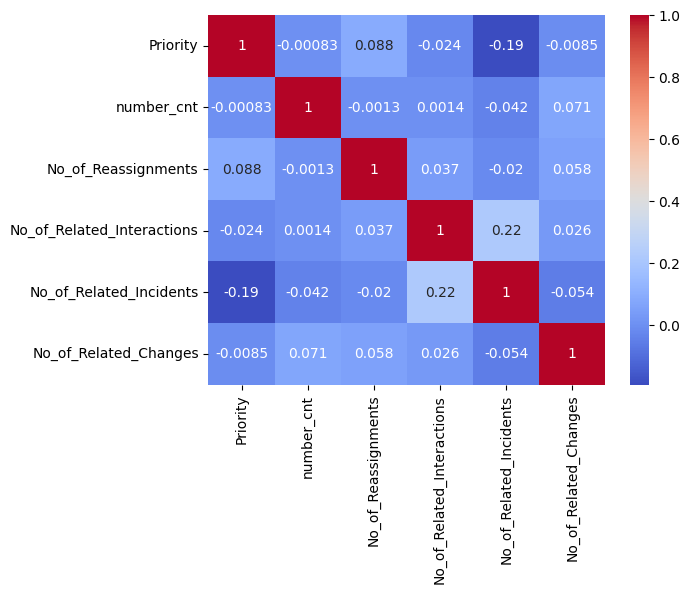

In [64]:

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap= "coolwarm"
)
plt.show()

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

def perform_eda(x_train):

    print("="*80)
    print("1. Shape")
    print("="*80)
    print(df.shape)

    print("\n","="*80)
    print("2. Data Types")
    print("="*80)
    print(df.dtypes)

    print("\n","="*80)
    print("3. Basic Information")
    print("="*80)
    print(df.info())

    print("\n","="*80)
    print("4. Missing Values")
    print("="*80)
    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": round(df.isnull().mean()*100,2)
    })
    print(missing[missing["Missing Count"]>0])

    print("\n","="*80)
    print("5. Duplicate Rows")
    print("="*80)
    print(df.duplicated().sum())

    print("\n","="*80)
    print("6. Statistical Summary")
    print("="*80)
    print(df.describe())

    print("\n","="*80)
    print("7. Numerical Columns")
    print("="*80)
    num_cols = df.select_dtypes(include=["number"]).columns
    print(list(num_cols))

    print("\n","="*80)
    print("8. Categorical Columns")
    print("="*80)
    cat_cols = df.select_dtypes(include=["object"]).columns
    print(list(cat_cols))

    print("\n","="*80)
    print("9. Cardinality")
    print("="*80)
    for col in df.columns:
        print(f"{col:<35} {df[col].nunique()}")

    print("\n","="*80)
    print("10. Unique Values (Top 10)")
    print("="*80)
    for col in cat_cols:
        print(f"\n{col}")
        print(df[col].value_counts().head(10))

    print("\n","="*80)
    print("11. Histograms")
    print("="*80)

    for col in num_cols:
        plt.figure(figsize=(5,3))
        df[col].hist(bins=30)
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

    print("\n","="*80)
    print("12. Boxplots")
    print("="*80)

    for col in num_cols:
        plt.figure(figsize=(5,2))
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(col)
        plt.show()

    print("\n","="*80)
    print("13. Correlation")
    print("="*80)

    if len(num_cols) > 1:
        print(df[num_cols].corr())

    print("\nEDA Completed Successfully.")

In [103]:
def preprocess(x_train,x_test):
    for i in x_train.select_dtypes(include=['number']).columns:
        if x_train[i].isnull().sum() < len(x_train) * 0.5:
            x_train[i] = x_train[i].fillna(x_train[i].median())
            x_test[i]= x_test[i].fillna(x_train[i].median())

    for i in x_train.select_dtypes(include=['object']).columns:
        if x_train[i].isnull().sum() < len(x_train) * 0.5:
            x_train[i] = x_train[i].fillna(x_train[i].mode()[0])
            x_test[i]= x_test[i].fillna(x_train[i].mode()[0])


    
    categorical_cols = x_train.select_dtypes(include=['object']).columns

    x_train[categorical_cols] = x_train[categorical_cols].astype(str)
    x_test[categorical_cols] = x_test[categorical_cols].astype(str)

    encoder = OrdinalEncoder(
        handle_unknown = "use_encoded_value",
        unknown_value = -1
    )

    x_train[categorical_cols] = encoder.fit_transform(x_train[categorical_cols])

    x_test[categorical_cols] = encoder.transform(x_test[categorical_cols])


    return x_train,x_test

In [40]:
times_cols

['Open_Time']

In [104]:
def feature_engineering(x_train,x_test,times_cols):

    for i in times_cols:
        x_train[f'{i}_year'] = x_train[i].dt.year
        x_train[f'{i}_month'] = x_train[i].dt.month
        x_train[f'{i}_day'] = x_train[i].dt.day
        x_train[f'{i}_hours'] = x_train[i].dt.hour
        x_train[f'{i}_minutes'] = x_train[i].dt.minute

        x_test[f'{i}_year'] = x_test[i].dt.year
        x_test[f'{i}_month'] = x_test[i].dt.month
        x_test[f'{i}_day'] = x_test[i].dt.day
        x_test[f'{i}_hours'] = x_test[i].dt.hour
        x_test[f'{i}_minutes'] = x_test[i].dt.minute


        x_train = x_train.drop(columns=times_cols)
        x_test = x_test.drop(columns=times_cols)
        

    return x_train,x_test

In [105]:
def eda_before_fe(x_train,y_train):
    print("="*80)
    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": round(df.isnull().mean()*100,2)
        })

    print(missing)
    print("="*80)
    print("Distribution")
    
    cols = x_train.hist(
        figsize=(15,10),
        bins=30
    )

    plt.tight_layout()
    plt.show()

    print("="*80)
    print("Outlier")
    outlier = df.boxplot(
        figsize=(15,10),
    )

    plt.tight_layout()
    plt.show()

    
    print("="*80)
    print("Heatmap")
    plt.figure(figsize=(16,12))

    sns.heatmap(
        x_train.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        annot_kws={"size":8}
     )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()  



    print("="*80)
    # Combine X and y
    train_df = x_train.copy()
    train_df["Priority"] = y_train

    plt.figure(figsize=(16,12))
 
    sns.heatmap(
        train_df.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [140]:
def feature_selection(x_train, x_test, y_train):

    selector = SelectFromModel(
        RandomForestClassifier(random_state=42)
    )

    selector.fit(x_train, y_train)

    selected_features = x_train.columns[selector.get_support()]

    print("Selected Features:")
    print(selected_features)

    x_train = pd.DataFrame(
        selector.transform(x_train),
        columns=selected_features,
        index=x_train.index
    )

    x_test = pd.DataFrame(
        selector.transform(x_test),
        columns=selected_features,
        index=x_test.index
    )

    return x_train, x_test

In [112]:
x_cols = [
    'CI_Name',
    'CI_Cat',
    'CI_Subcat',
    'WBS',
    'number_cnt',
    'Category',
    'KB_number',
    'Open_Time'
]
x = df[x_cols]
y = df["Priority"]

In [118]:
x_cols = [
    'CI_Name',
    'CI_Cat',
    'CI_Subcat',
    'WBS',
    'number_cnt',
    'Category',
    'KB_number',
    'Open_Time'
]

x = df[x_cols]
y = df["Priority"]

In [62]:
x

,CI_Name,CI_Cat,CI_Subcat,WBS,Impact,Urgency,number_cnt,Category,KB_number,Open_Time
0,SUB000508,subapplication,Web Based Application,WBS000162,4,4,0.601292,incident,KM0000553,05-02-2012 13:32
1,WBA000124,application,Web Based Application,WBS000088,3,3,0.415050,incident,KM0000611,12-03-2012 15:44
3,WBA000124,application,Web Based Application,WBS000088,4,4,0.642927,incident,KM0000611,17-07-2012 11:49
4,WBA000124,application,Web Based Application,WBS000088,4,4,0.345258,incident,KM0000611,10-08-2012 11:01
5,WBA000124,application,Web Based Application,WBS000088,4,4,0.006676,incident,KM0000611,10-08-2012 11:27
...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,4,4,0.231896,incident,KM0001314,31-03-2014 16:23
46602,SBA000461,application,Server Based Application,WBS000073,4,4,0.805153,incident,KM0002360,31-03-2014 15:03
46603,LAP000019,computer,Laptop,WBS000091,5,5,0.917466,incident,KM0000315,31-03-2014 15:28
46604,WBA000058,application,Web Based Application,WBS000073,4,4,0.701278,incident,KM0001287,31-03-2014 15:35


In [28]:
y.isnull().sum()

0

In [141]:
def prepare_data(x, y, times_cols):
    x_train, x_test, y_train, y_test = split_data(x, y)
    x_train, x_test = clean_data(x_train, x_test, times_cols)
    eda_before_fe(x_train,y_train)
    x_train, x_test = preprocess(x_train, x_test)
    x_train, x_test = feature_engineering(x_train, x_test, times_cols)
    eda_before_fe(x_train,y_train)
    x_train, x_test = feature_selection(
        x_train,
        x_test,
        y_train
    )
    return x_train, x_test, y_train, y_test

In [143]:
def model_training(x, y, times_cols):

    x_train, x_test, y_train, y_test = prepare_data(
        x,
        y,
        times_cols
    )

    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42,class_weight="balanced"),
       
    }
    print(x_train.dtypes)
    print(x_train.columns)
    print(x_train.shape)
    print(type(x_train))

    for name, model in models.items():
        model.fit(x_train, y_train)

        predictions = model.predict(x_test)

        accuracy = accuracy_score(y_test, predictions)

        print(f"{name} Accuracy: {accuracy:.4f}")

        print(classification_report(y_test, predictions))

        train_pred = model.predict(x_train)

        # Test predictions
        test_pred = model.predict(x_test)

        # Accuracy
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        print(f"Train Accuracy : {train_acc:.4f}")
        print(f"Test Accuracy  : {test_acc:.4f}")

                            Missing Count  Missing %
CI_Name                                 0       0.00
CI_Cat                                108       0.24
CI_Subcat                             108       0.24
WBS                                     0       0.00
Incident_ID                             0       0.00
Status                                  0       0.00
Impact                                  0       0.00
Urgency                                 0       0.00
Priority                                0       0.00
number_cnt                              0       0.00
Category                                0       0.00
KB_number                               0       0.00
Alert_Status                            0       0.00
No_of_Reassignments                     1       0.00
Open_Time                               0       0.00
Reopen_Time                         42987      95.05
Resolved_Time                        1644       3.64
Close_Time                              0     

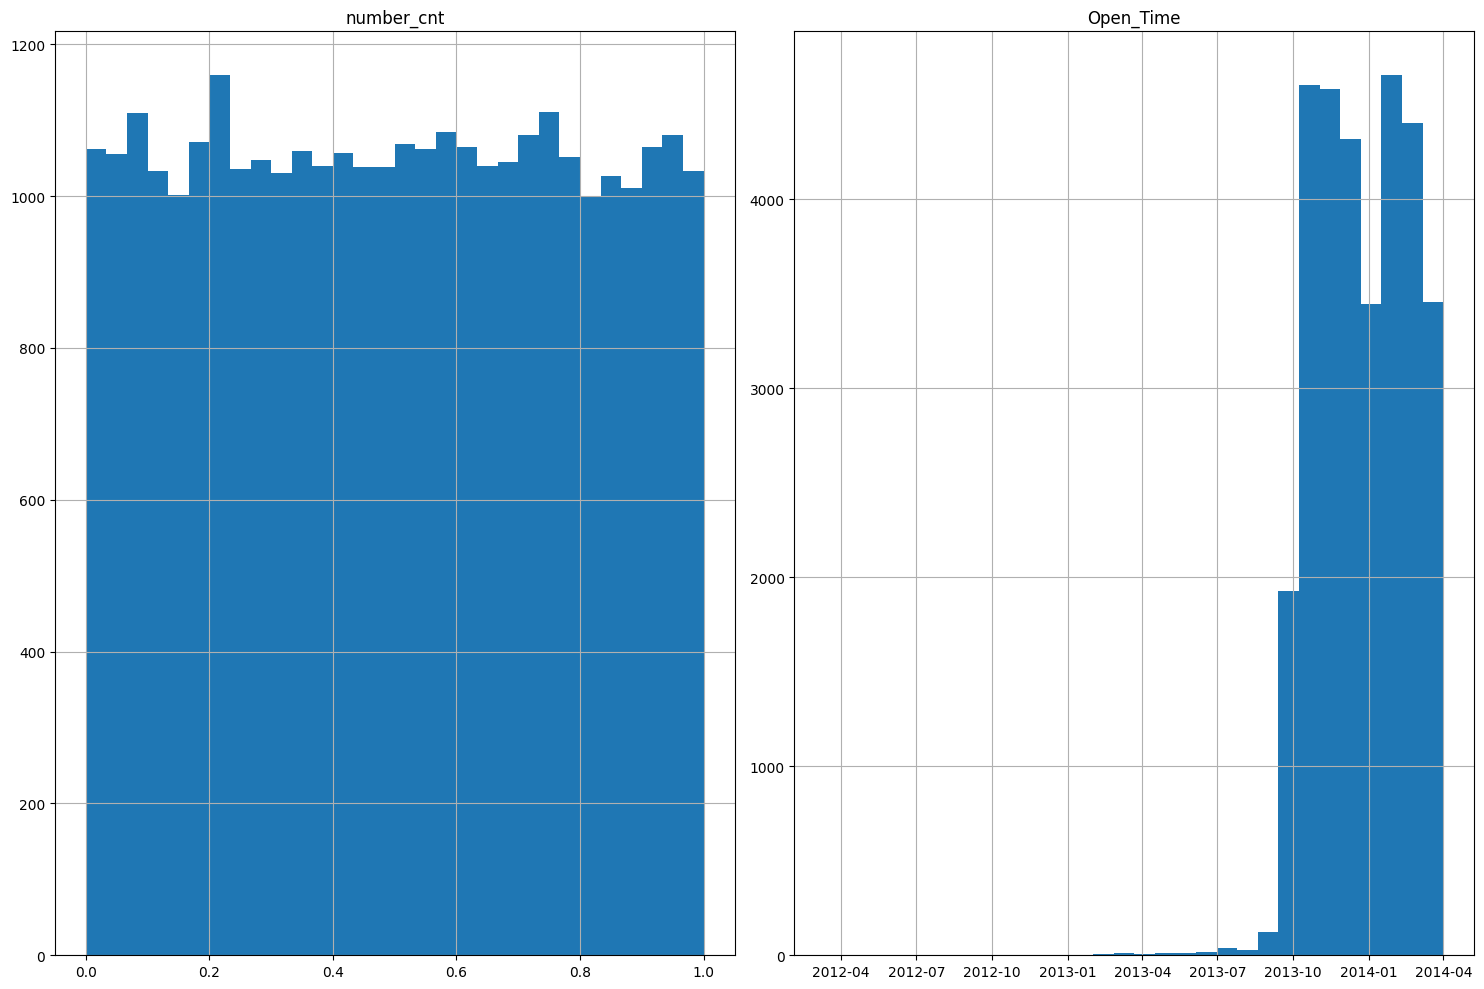

Outlier


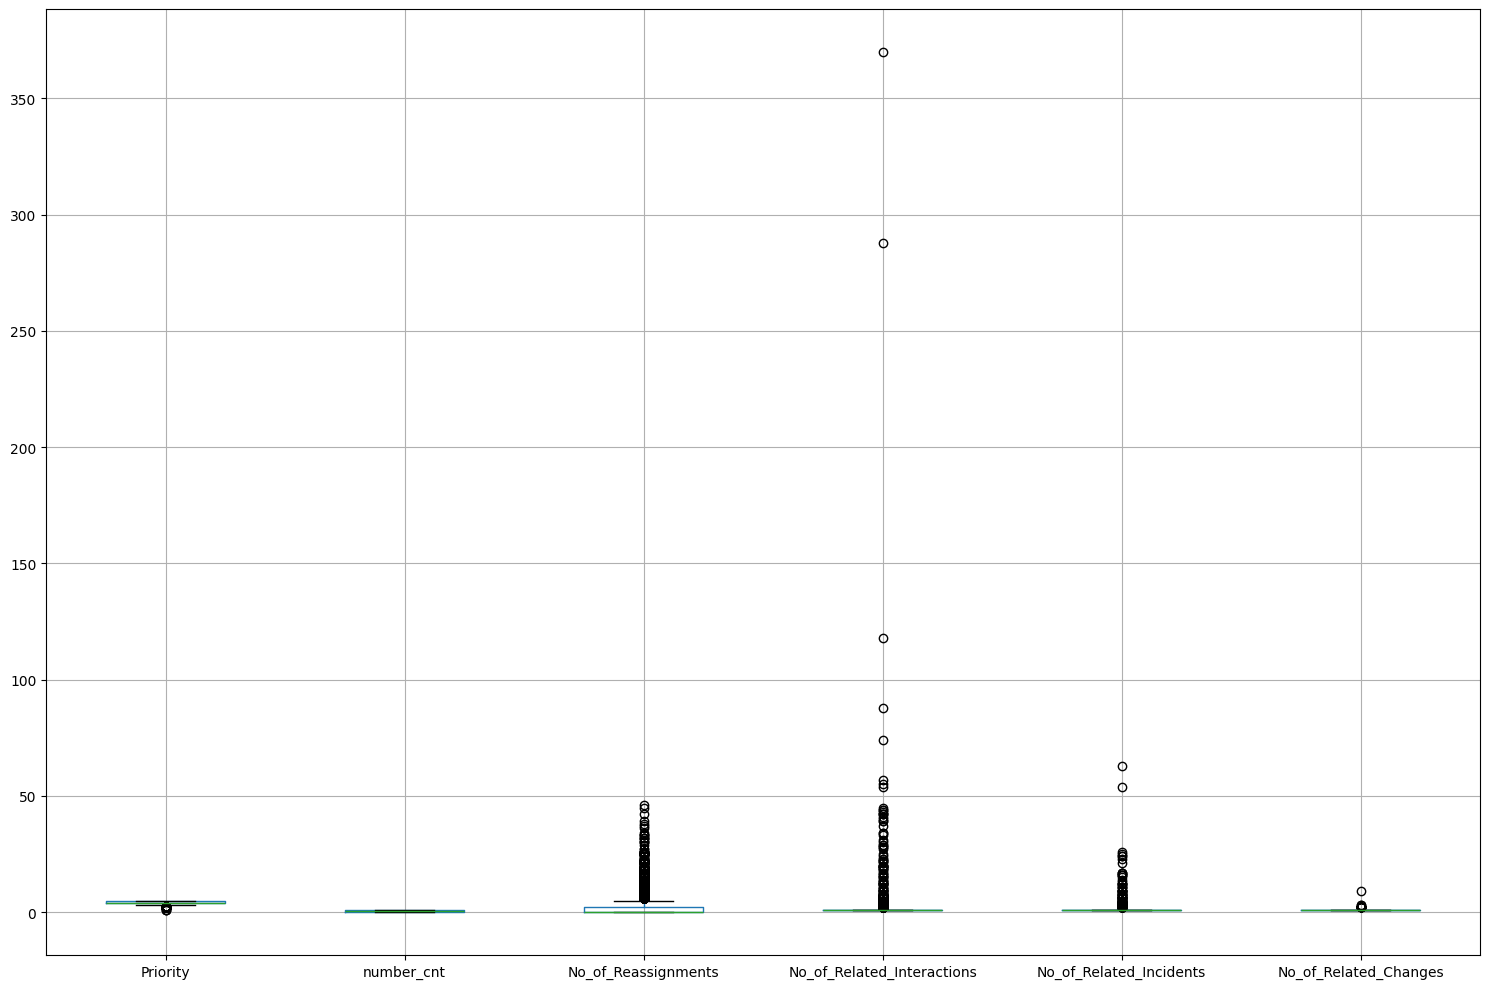

Heatmap


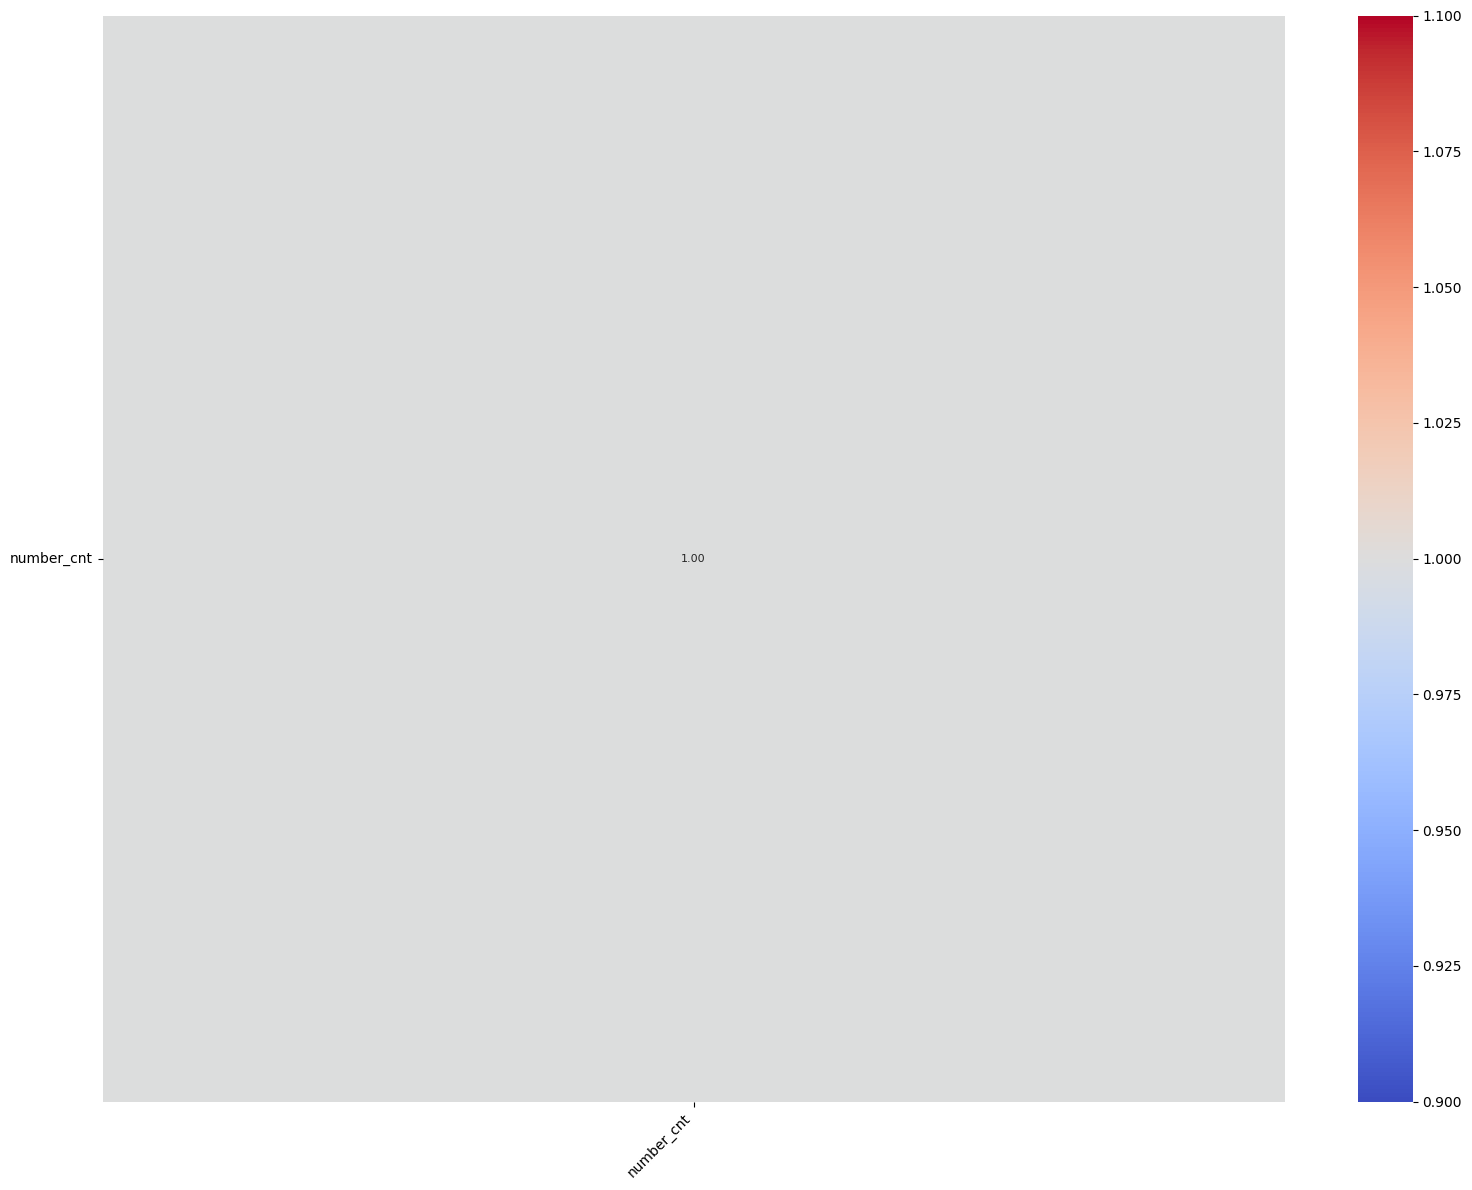

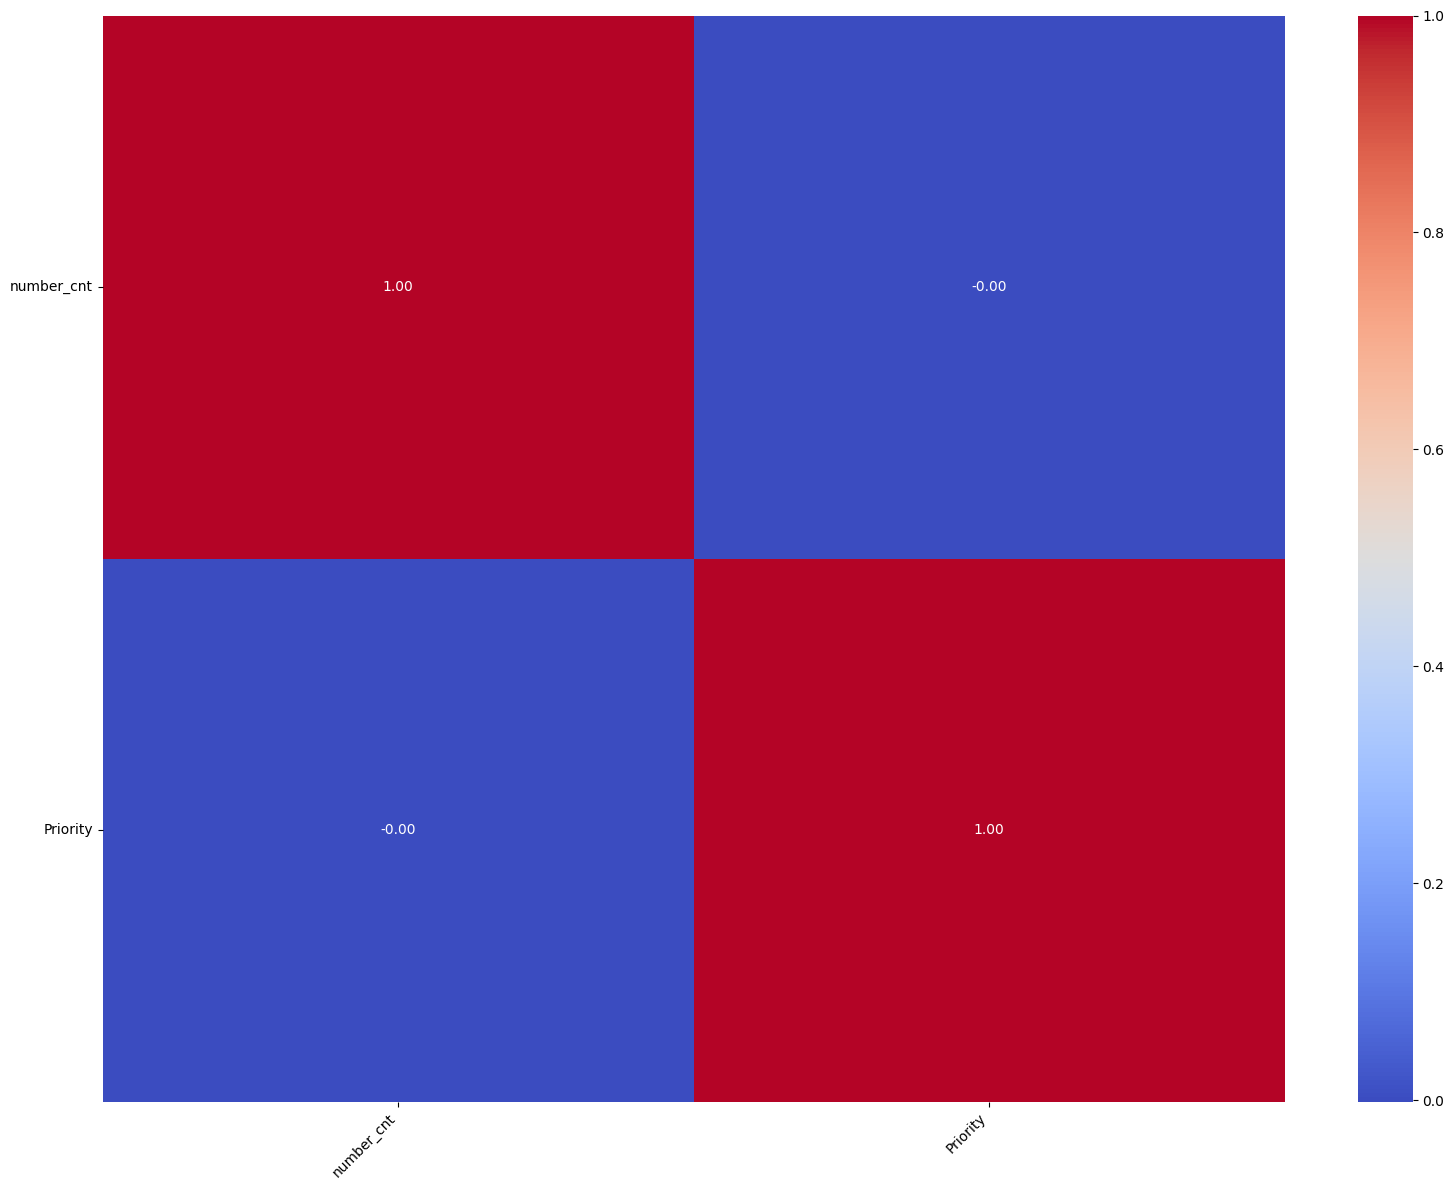

                            Missing Count  Missing %
CI_Name                                 0       0.00
CI_Cat                                108       0.24
CI_Subcat                             108       0.24
WBS                                     0       0.00
Incident_ID                             0       0.00
Status                                  0       0.00
Impact                                  0       0.00
Urgency                                 0       0.00
Priority                                0       0.00
number_cnt                              0       0.00
Category                                0       0.00
KB_number                               0       0.00
Alert_Status                            0       0.00
No_of_Reassignments                     1       0.00
Open_Time                               0       0.00
Reopen_Time                         42987      95.05
Resolved_Time                        1644       3.64
Close_Time                              0     

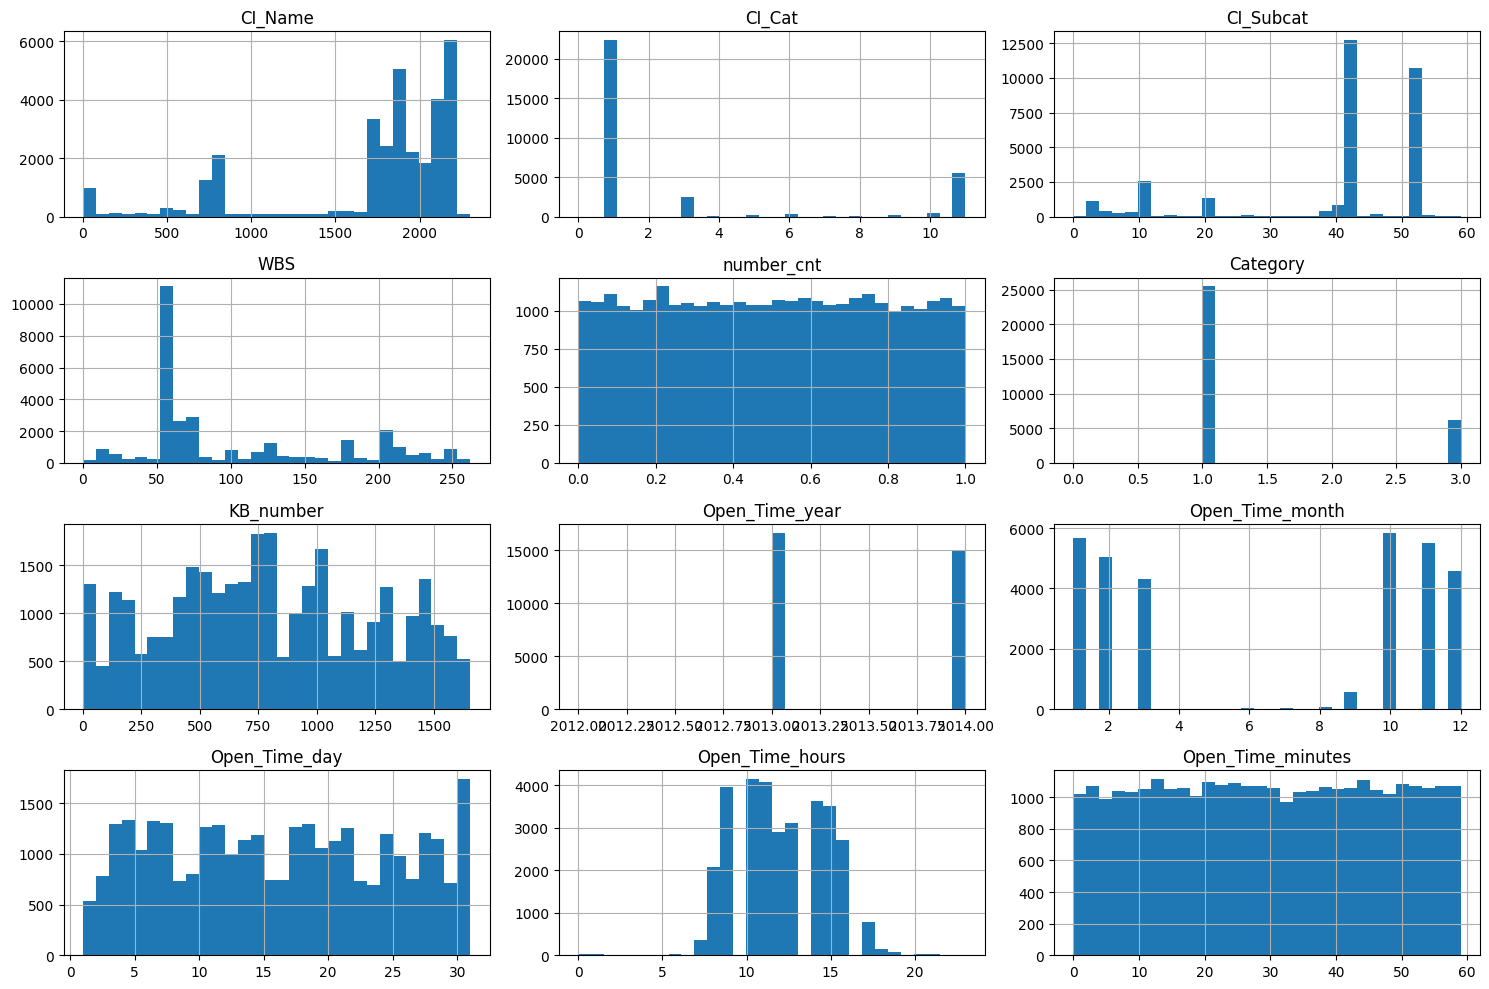

Outlier


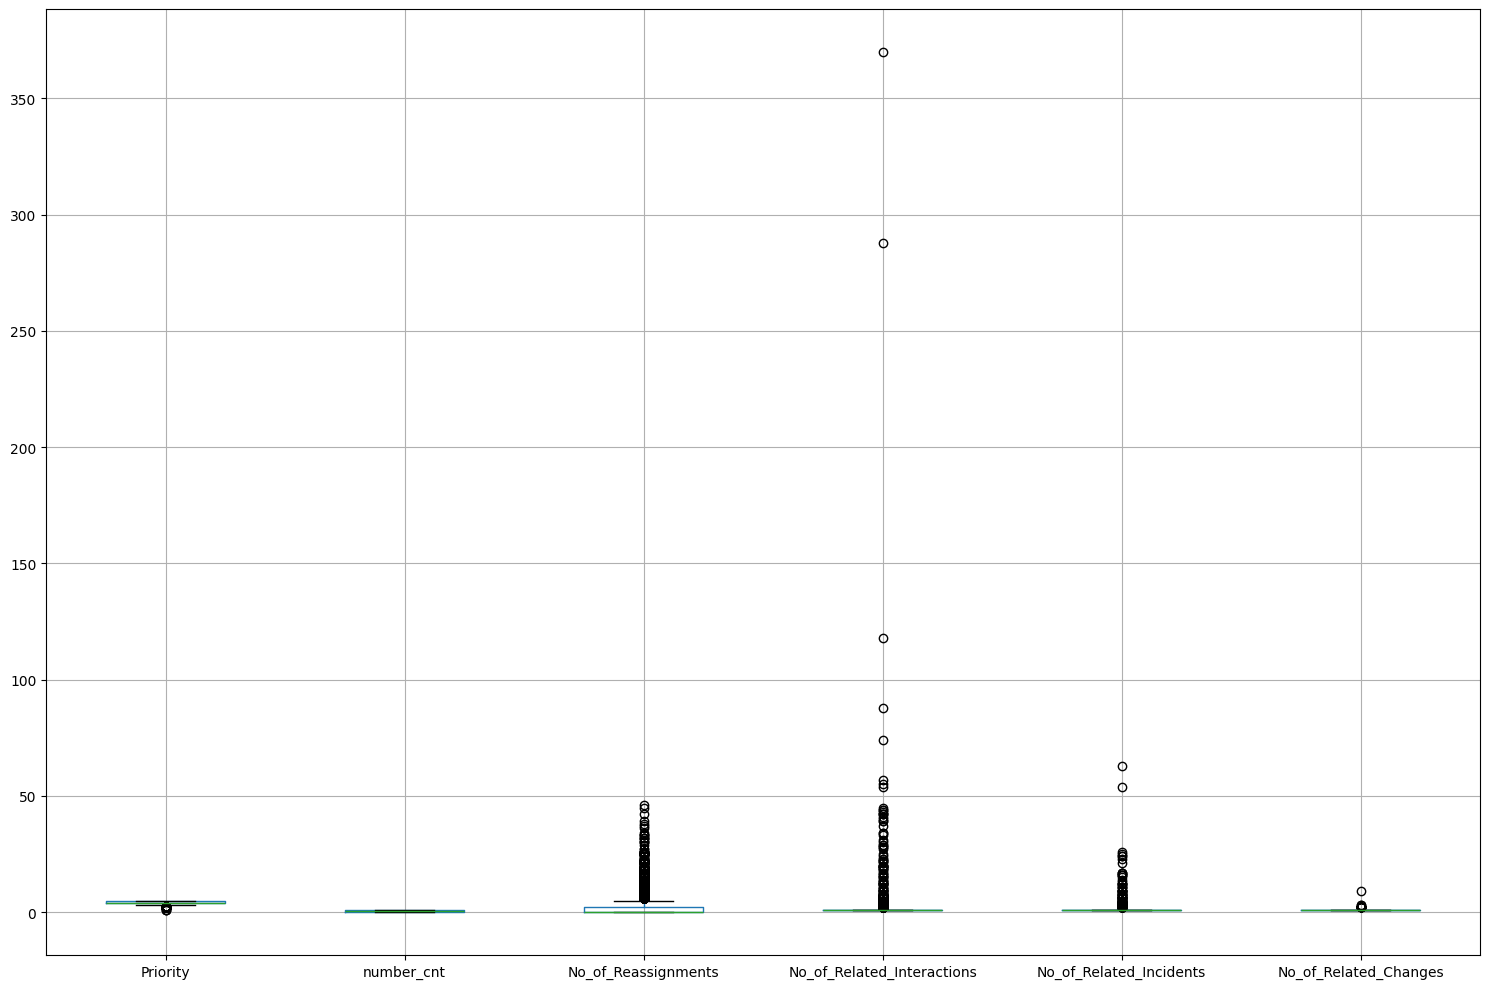

Heatmap


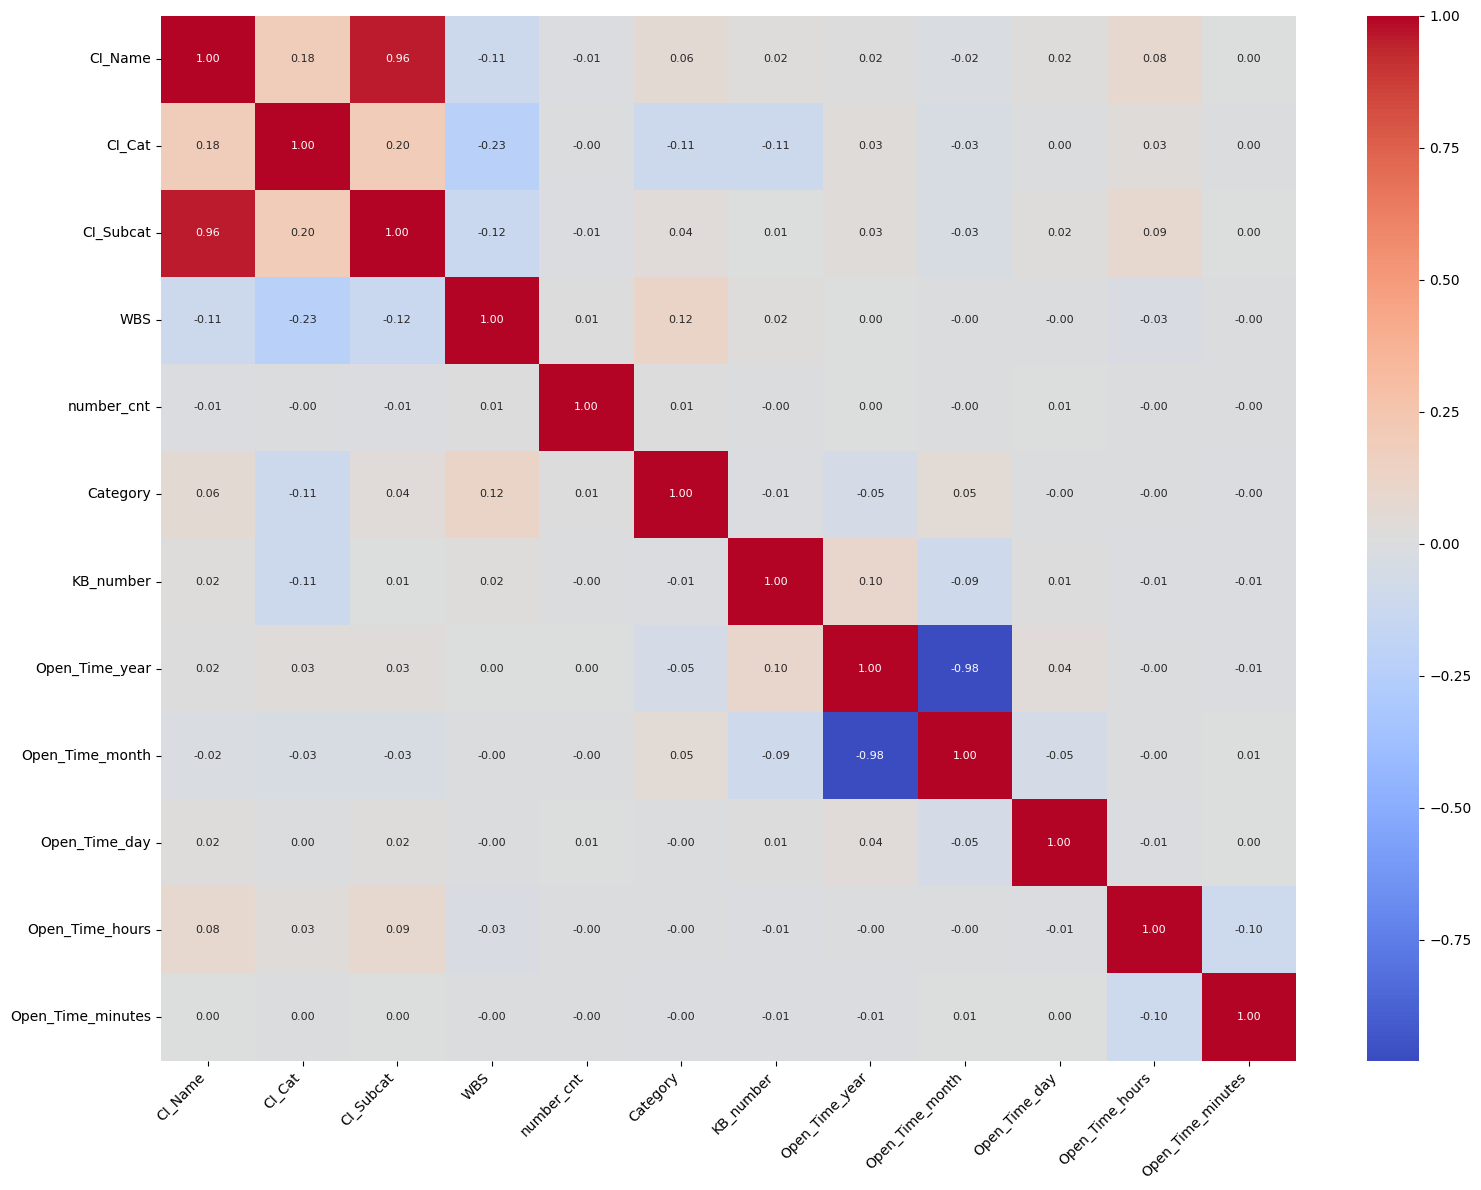

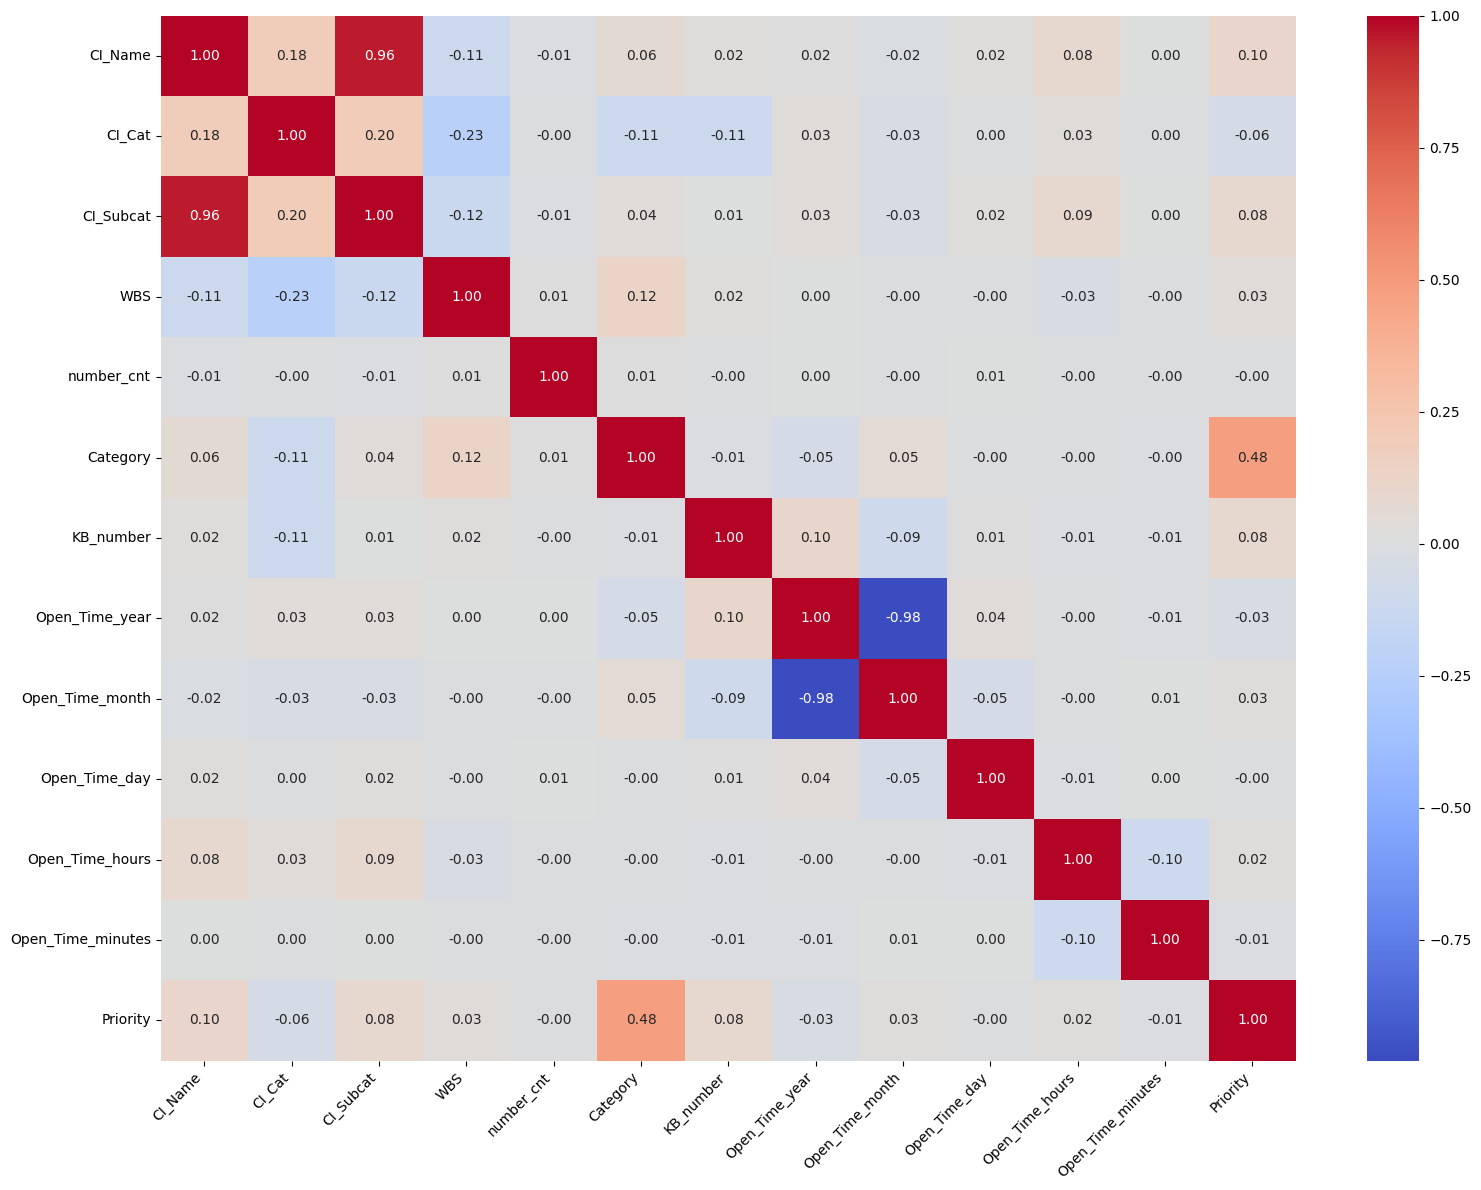

Selected Features:
Index(['CI_Name', 'WBS', 'Category', 'KB_number'], dtype='object')
CI_Name      float64
WBS          float64
Category     float64
KB_number    float64
dtype: object
Index(['CI_Name', 'WBS', 'Category', 'KB_number'], dtype='object')
(31658, 4)
<class 'pandas.core.frame.DataFrame'>
Decision Tree Accuracy: 0.8889
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.55      0.27      0.36       209
         3.0       0.80      0.76      0.78      1597
         4.0       0.87      0.95      0.91      6815
         5.0       0.95      0.87      0.91      4946

    accuracy                           0.89     13568
   macro avg       0.64      0.57      0.59     13568
weighted avg       0.89      0.89      0.89     13568

Train Accuracy : 0.9441
Test Accuracy  : 0.8889


C:\Users\Admin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Gradient Boosting Accuracy: 0.8267
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.70      0.38      0.50       209
         3.0       0.63      0.59      0.61      1597
         4.0       0.83      0.94      0.88      6815
         5.0       0.90      0.77      0.83      4946

    accuracy                           0.83     13568
   macro avg       0.61      0.54      0.56     13568
weighted avg       0.83      0.83      0.82     13568

Train Accuracy : 0.8511
Test Accuracy  : 0.8267
Random Forest Accuracy: 0.8666
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.20      0.44      0.27       209
         3.0       0.64      0.81      0.72      1597
         4.0       0.93      0.89      0.91      6815
         5.0       0.96      0.87      0.91      4946

    accuracy                           0.87     13568
   macro avg     

In [144]:
model_training(x, y, times_cols)

In [96]:
df["Priority"].value_counts()

Priority
4.0    22717
5.0    16486
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64

In [6]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [89]:
pd.crosstab(
    [df["Impact"], df["Urgency"]],
    df["Priority"]
)

Priority             1.0  2.0   3.0    4.0    5.0
Impact Urgency                                   
1      1               3    0     0      0      0
2      2               0  533     0      0      0
       3               0    2     0      0      0
       2               0  156     0      0      0
       3               0    1     0      0      0
3      2               0    3     0      0      0
       3               0    0  3420      0      0
       4               0    0   111      0      0
       5               0    0     0      4      0
       1               0    2     0      0      0
       3               0    0  1657      0      0
       4               0    0    33      0      0
       5               0    0     0      4      0
4      2               0    0     2      0      0
       3               0    0    76      0      0
       4               0    0     0  15223      0
       5               0    0     0    239      0
       2               0    0     1      0      0
       3               0    0    21      0      0
       4               0    0     0   6947      0
       5               0    0     0     47      0
5      1               0    0     1      0      0
       3               0    0     0      9      0
       4               0    0     0    172      0
       5               0    0     0      0  12041
       2               0    0     1      0      0
       3               0    0     0      2      0
       4               0    0     0     70      0
       5               0    0     0      0   4444
       5 - Very Low    0    0     0      0      1